<a href="https://colab.research.google.com/github/CODERNSINGH/100-days-of-machine-learning/blob/main/DL_Overfitting_Underfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Underfitting, Overfitting and Regularisation

We have a training set with two classes. We want a model that draws the boundary between them.

We train three models that differ only in size, look at the boundary each one draws, and read the training and validation loss curves. Then we take the worst of the three and try to repair it with L2, L1 and dropout.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from sklearn.datasets import make_moons
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

In [ ]:
# colours used by every plot below
BLUE = "#1C7ED6"
ORANGE = "#F76707"
GREEN = "#2F9E44"
PURPLE = "#AE3EC9"

# pale background for the boundary plots, and the two point colours
BACKGROUND = LinearSegmentedColormap.from_list("bg", ["#FFE0CC", "#FFFFFF", "#CFE8FF"])
POINTS = ListedColormap([ORANGE, BLUE])

## The data

150 points for training, 2000 points held back for validation. The model only ever computes gradients on the 150.

In [ ]:
X, y = make_moons(n_samples=2150, noise=0.3, random_state=0)

Xtr, ytr = X[:150], y[:150]
Xva, yva = X[150:], y[150:]

print("training set", Xtr.shape)
print("validation set", Xva.shape)

training set (150, 2)
validation set (2000, 2)


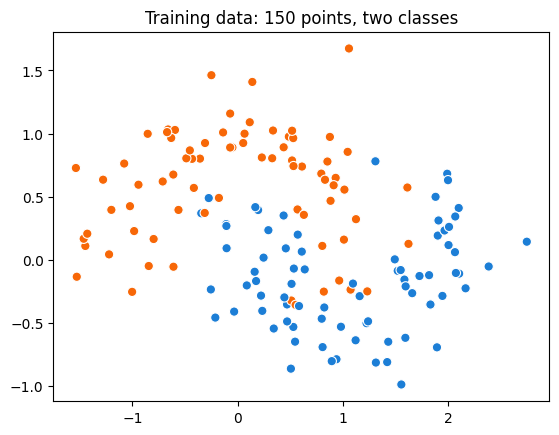

In [ ]:
plt.scatter(Xtr[:, 0], Xtr[:, 1], c=ytr, cmap=POINTS, edgecolors="white", linewidth=0.8, s=45)
plt.title("Training data: 150 points, two classes")
plt.show()

The two classes overlap. There is no boundary that separates the training points perfectly, so any model that classifies all 150 correctly has done something we do not want.

## Two helpers

One to draw the loss curves, one to draw the boundary a model has learned. The background colour is the probability the model assigns to the blue class, and the black line is where that probability is 0.5.

Each boundary is drawn twice, in two separate cells. The first shows the 150 training points the model was fitted to. The second shows 150 of the validation points the model has never seen. The boundary is the same in both, only the points change. All 2000 validation points are still used for the validation loss, the plot just draws 150 of them so it stays readable.

In [ ]:
def plot_loss(history, title, ymax=1):
    plt.plot(history.history["loss"], color=BLUE, linewidth=2, label="training")
    plt.plot(history.history["val_loss"], color=ORANGE, linewidth=2, label="validation")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.ylim(0, ymax)
    plt.title(title)
    plt.legend()
    plt.show()

In [ ]:
def plot_boundary(model, title, validation=False):
    xx, yy = np.meshgrid(np.linspace(-2.5, 3.5, 300), np.linspace(-2.5, 3, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid, verbose=0).reshape(xx.shape)

    if validation:
        # only the first 150 validation points are drawn, so the plot is not
        # crowded. All 2000 are still used to compute the validation loss.
        points, labels, name = Xva[:150], yva[:150], "validation points"
    else:
        points, labels, name = Xtr, ytr, "training points"

    plt.contourf(xx, yy, Z, levels=50, cmap=BACKGROUND)
    plt.contour(xx, yy, Z, levels=[0.5], colors="#212529", linewidths=2)
    plt.scatter(points[:, 0], points[:, 1], c=labels, cmap=POINTS,
                edgecolors="white", linewidth=0.8, s=45)
    plt.title(title + ", " + name)
    plt.show()

Every model below is trained the same way, so we write that once too. Full batch, 400 epochs.

In [ ]:
def train(model):
    model.compile(optimizer=keras.optimizers.Adam(0.003),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model.fit(Xtr, ytr,
                     validation_data=(Xva, yva),
                     epochs=400, batch_size=150, verbose=2)

---
## Model 1: one hidden layer, 4 units